In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [13]:
train_df = pd.read_csv("data/train.csv")

In [14]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('SalePrice')  # drop target and Id if present
numeric_cols = numeric_cols.drop('Id', errors='ignore')
print(len(numeric_cols))

36


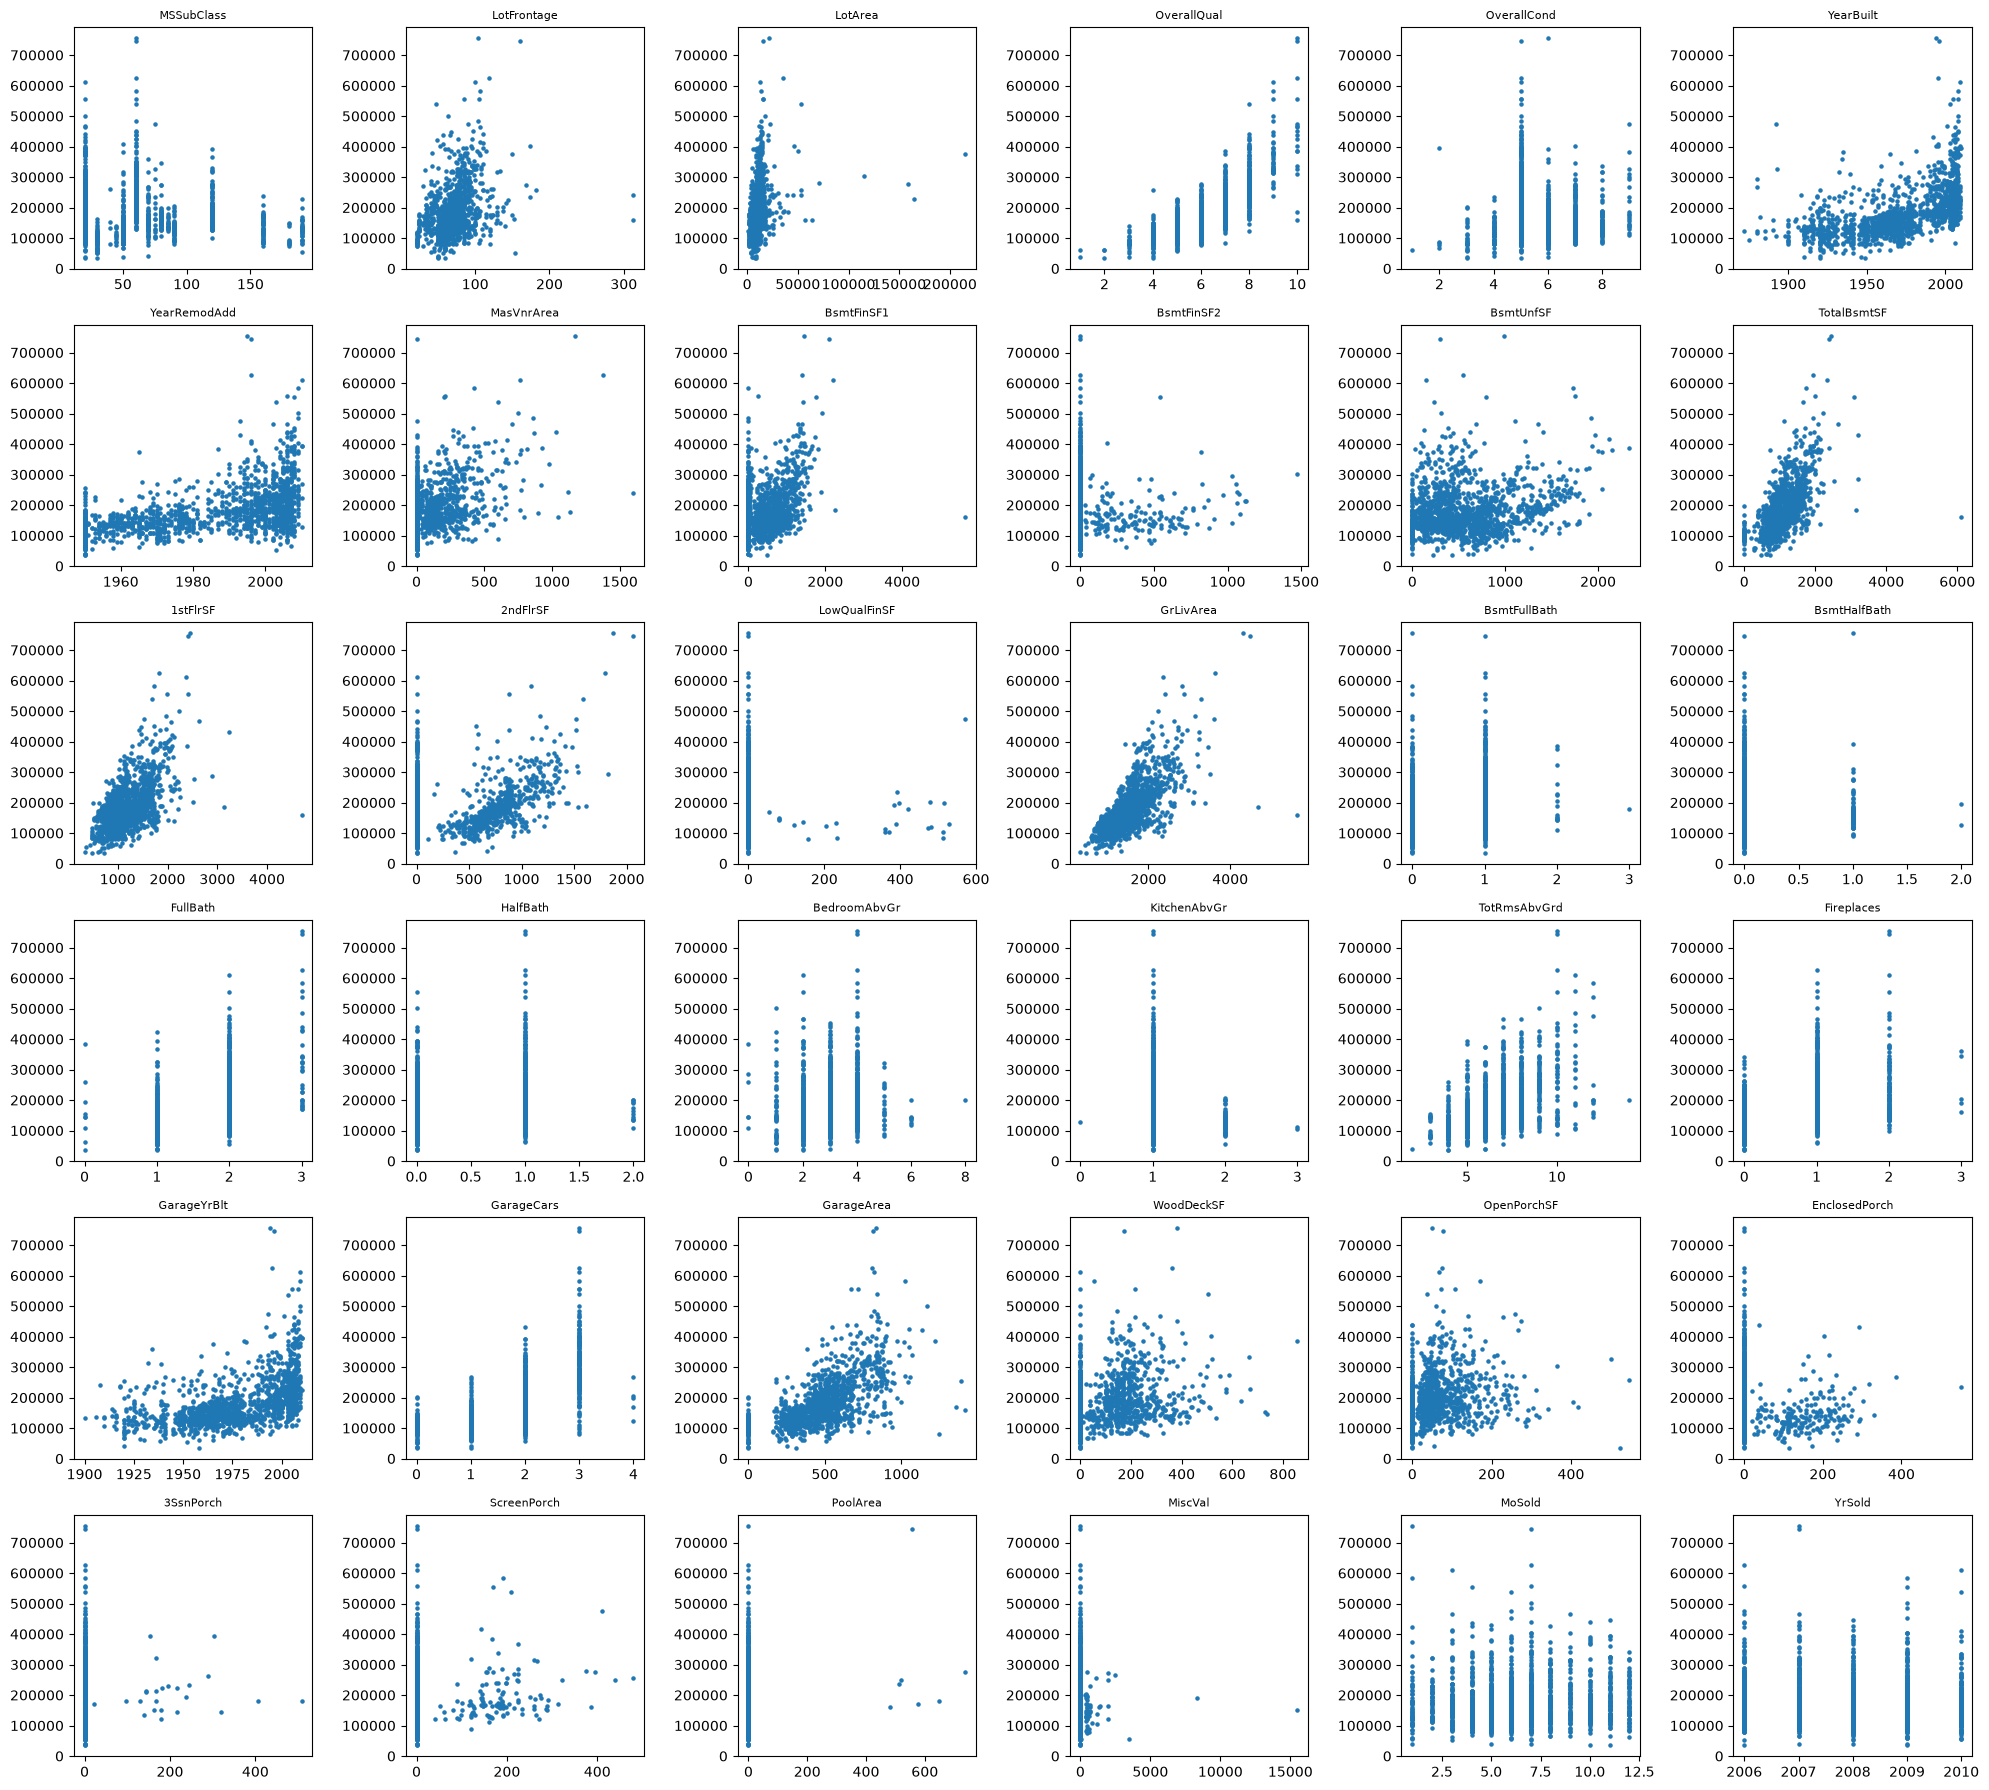

In [15]:
# Plot a grid of scatter plots to identify outliers
n = len(numeric_cols)
ncols = 6
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(train_df[col], train_df['SalePrice'], s=5)
    axes[i].set_title(col, fontsize=8)

# hide any unused subplot axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [16]:
outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
print(outliers[['GrLivArea', 'SalePrice', 'SaleCondition']])

      GrLivArea  SalePrice SaleCondition
523        4676     184750       Partial
1298       5642     160000       Partial


In [17]:
# Removed N rows with GrLivArea > 4000 and SaleCondition = Partial — these are new-construction sales priced before completion, 
# not representative of the normal completed-home sales the model is meant to predict.
train_df = train_df[~((train_df['GrLivArea'] > 4000) & (train_df['SaleCondition'] == 'Partial'))]

In [18]:
train_df[(train_df['TotalBsmtSF'] > 3000)][['TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'SalePrice', 'SaleCondition']]

,TotalBsmtSF,1stFlrSF,GrLivArea,SalePrice,SaleCondition
332,3206,1629,1629,284000,Normal
440,3094,2402,2402,555000,Normal
496,3200,3228,3228,430000,Normal


In [19]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

PoolQC          1452
MiscFeature     1404
Alley           1367
Fence           1177
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [20]:
# Bucket 1: NaN = feature doesn't exist -> "None"
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtFinType2', 'BsmtExposure', 'BsmtFinType1', 'BsmtCond', 'BsmtQual']
train_df[none_cols] = train_df[none_cols].fillna('None')

# Bucket 2: genuinely missing -> real imputation
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna(0)
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)
train_df['Electrical'] = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])

# LotFrontage: fill by neighborhood median rather than a single global median
train_df['LotFrontage'] = train_df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

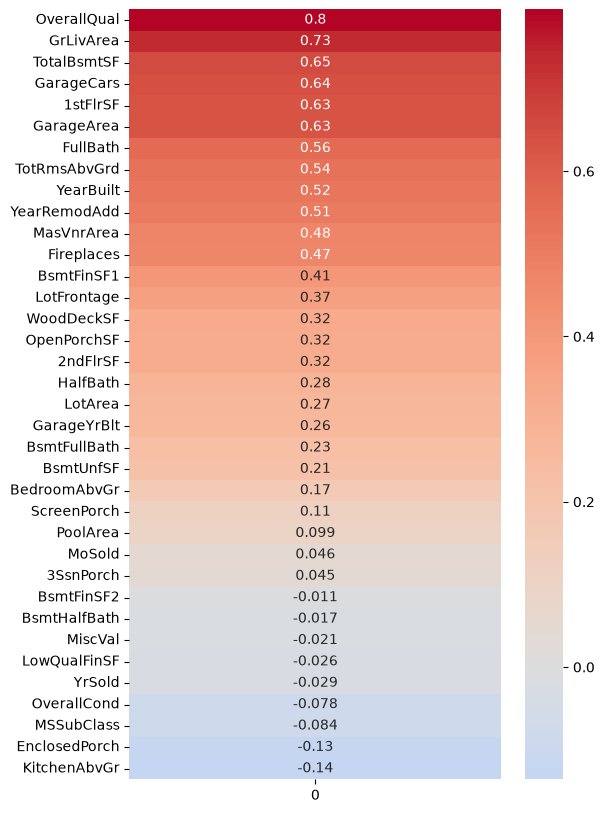

In [21]:
correlations = train_df[numeric_cols].corrwith(train_df['SalePrice']).sort_values(ascending=False)
plt.figure(figsize=(6, 10))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', center=0)
plt.show()

In [22]:
y = np.log1p(train_df['SalePrice'])

In [23]:
categorical_features = ['Neighborhood', 'HouseStyle', 'ExterQual']  # pick a handful, your call

X_numeric = train_df[numeric_cols].drop(columns=['SalePrice'], errors='ignore')
X_categorical = pd.get_dummies(train_df[categorical_features])

X = pd.concat([X_numeric, X_categorical], axis=1)
y = np.log1p(train_df['SalePrice'])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, preds))
print(f"Linear Regression RMSE: {rmse:.4f}")


Linear Regression RMSE: 0.1292


In [25]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, preds))
print(f"Random Forest Regressor RMSE: {rmse:.4f}")

Random Forest Regressor RMSE: 0.1489


In [27]:
model = XGBRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, preds))
print(f"XGBoost RMSE: {rmse:.4f}")

XGBoost RMSE: 0.1518
